### Module 2
**1. tools_messages**

**2. chains_reducers**


#### Tools Messages (Tool Calling)

In [5]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

messages = [AIMessage(content=f"So you said you were researching about ai research engineers?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right", name="Moiz"))
messages.append(AIMessage(content=f"Great! What specific aspects of ai research engineering are you interested in?", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about those people who works in openai, deepmind, what are their mindset"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching about ai research engineers?
================================ Human Message =================================
Name: Moiz

Yes, that's right
================================== Ai Message ==================================
Name: Model

Great! What specific aspects of ai research engineering are you interested in?
================================ Human Message =================================

I want to learn about those people who works in openai, deepmind, what are their mindset


In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")


In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(model = "gemini-2.5-flash")

In [8]:
simple_call = llm.invoke("Hi")
simple_call.content

'Hi there! How can I help you today?'

##### Tools are useful whenever you want a model to interact with external system
- Externla systems (e.g., API's) often require a particular input schema or payload, rather than natural language.
- when we bind an API, for example, as a tool we given the model awareness of the required input schema.
- The model will choose to call a tool based upon the natural language input from the user.
- And it will return an output that adheres to the tool's schema.
- Many LLM providers support tool calling and tool calling interface in langchain is simple
- We can simply pass any python function into ChatModel.bind_tools(function)

In [9]:
def deposit_money(name: str, bank_account_no: int, amount: int) -> str:
    """
    Deposit Money in Bank Account

    Args:
        name: account holder name
        bank_account_no: bank account id
        amount: amount to be deposited

    Returns:
        str: deposit status
    """

    #Business Logic for Bank Deposit
    return f"Deposit {amount} Sucessful in {name} Account"

In [10]:
deposit_money(name="Moiz", bank_account_no=1122334455, amount=500)

'Deposit 500 Sucessful in Moiz Account'

In [11]:
llm_with_tools = llm.bind_tools([deposit_money])

In [12]:
llm_with_tools

_ChatModelBinding(bound=ChatGoogleGenerativeAI(output_version=None, profile={'name': 'Gemini 2.5 Flash', 'release_date': '2025-03-20', 'last_updated': '2025-06-05', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-2.5-flash', client=<google.genai.client.Client object at 0x0000020658ED5550>, default_metadata=(), model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'deposit_money', 'description': 'Deposit Money in Bank Account', 'parameters': {'properties': {'name': {'description

In [13]:
from langchain_core.messages import HumanMessage

call = llm.invoke(
    [HumanMessage(content=f"Deposit 200 in Ahmad Account. His acc number is 5544332211", name="Muhammad")]
)

call

AIMessage(content='I cannot directly process financial transactions or deposit money into a real bank account. As an AI, I don\'t have access to banking systems or the capability to handle real-world funds.\n\nTo deposit 200 into Ahmad\'s account (number 5544332211), you would need to use one of the following methods through your own bank:\n\n1.  **Online Banking:** Log in to your bank\'s online portal, go to the "Transfers" or "Payments" section, and initiate a transfer to a third-party account. You\'ll need Ahmad\'s account number (5544332211) and possibly his full name.\n2.  **Mobile Banking App:** Use your bank\'s mobile application, which typically has similar functionality to online banking for transfers.\n3.  **Bank Branch:** Visit a physical branch of your bank and speak to a teller. Provide them with the amount (200), Ahmad\'s account number (5544332211), and his name.\n4.  **ATM (if applicable):** Some ATMs allow cash or cheque deposits to other accounts, but this varies by b

In [14]:
call = llm_with_tools.invoke(
    [HumanMessage(content=f"Deposit 200 in Ahmad Account. His acc number is 5544332211", name="junaid")]
)

call

AIMessage(content='', additional_kwargs={'function_call': {'name': 'deposit_money', 'arguments': '{"amount": 200, "bank_account_no": 5544332211, "name": "Ahmad"}'}, '__gemini_function_call_thought_signatures__': {'1974942d-5c2a-4b07-af35-bc7f3f6ceb9a': 'CoUDAQw51sdjKu7pehhBWdSGHNDFpi1Leu96ZPItGFpJZhP7vk5lg/T6ETlw06ywOHiE+yszSU/mLl3TBkWL11Am7mX9Y/sslu40sqodJV5DSL0KRWJ7ag7ZU6Rx0/XB5d4JI5rLmiZDLKksjqVxx+RsTxzrEQ12apo5nG/MYwGvdVBBlRww4GOYGpkEEwPSx8PR8vzBB0vFQg1pfk+FYFGO4dMa+0ph8mtucE1U/OSkJjpRc1HkHddgWt30gp217xE6Y08sitUNXh0P6WmTsC0V0iOjHUx9C7fm/ljR2/ykfdTmlMwyoqDYrNQvObxcUNZ6HXUGdoOrZ5Otjv1gFqy4SFJeDKTXsxTVrwCty9rrYTODUWIog+5q3EDPcNrl23zNhyCHJcnEzMjKHMMeUg7RS/7FFEwgBw2gjS/WPSYgGOq7mDUcuM5ah1/YpVLiGkH90wpbaezsWtthDJLqGP8WlDtFreK0nTtWgsgiIL1dVJVnhj+LsJYeatTbnZeWAWEPq7s2CR0='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb6d8-d56f-7ab1-a446-d1ada93a6367-0', tool_calls=[{'name': 'deposit

In [16]:
# Building Graph
from typing_extensions import TypedDict

class LastMessageState(TypedDict):
    messages: list

# 1. too calling - LLM Node
def call_llm(state: LastMessageState):
    messages = state["messages"]
    call_response = llm_with_tools.invoke(messages)
    
    return {"messages": [call_response]}

# 2. Graph
from langgraph.graph import StateGraph, START, END
builder: StateGraph = StateGraph(LastMessageState)

# define nodes
builder.add_node("call_llm_with_tools", call_llm)

# define edges
builder.add_edge(START, "call_llm_with_tools")
builder.add_edge('call_llm_with_tools', END)

# build graph
graph = builder.compile()

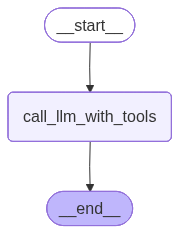

In [17]:
from IPython.display import display, Image
display (Image(graph.get_graph().draw_mermaid_png()))

In [18]:
graph.invoke({"messages": [HumanMessage(content = "Hi")]})

{'messages': [AIMessage(content="Hello! I can help you deposit money into a bank account. What is the account holder's name, bank account number, and the amount you would like to deposit?", additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb6f9-f4a4-7522-ab03-4e2ab2139f1f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 76, 'output_tokens': 35, 'total_tokens': 111, 'input_token_details': {'cache_read': 0}})]}

In [20]:
graph.invoke({"messages": [HumanMessage(content = "Deposit 10000 in Ali account, his bank accountn num is 0011")]})

{'messages': [AIMessage(content='', additional_kwargs={'function_call': {'name': 'deposit_money', 'arguments': '{"amount": 10000, "bank_account_no": 11, "name": "Ali"}'}, '__gemini_function_call_thought_signatures__': {'1460d1c5-4a3c-448c-81c6-e2f85ead9c05': 'Co0DAQw51sf9bM0F/rMCRvsz11WttSUOajI1k1KDDzzzwm9lXL59vDUtYJ3Uu+AiSRCc17w0qaCclQhnA6UGrOJaB7NJbcZFQ8U6DQrfgdmZJoR7624f5rf35b1pC+rQQPtUpkgRKG1gD9h5sfnBROMdBcq6Mk1Z7sj8bfDb7mQFWDyQb8CG5DUYGLvnl/15XzXKmUKRJ31U/sNz5D2rP3AlY62/7YjWp1nKogNj+Krh0Yt/+BNWs6gQs7Btyoh7joHIdR0zSSnHhU/pZ6rx3UUB/xSXBR21qaWqXtiZ3p4xmJxoaSXTsDYCoUqt4dPbZmpzJSsD1gtE18HVNtfWhnn4AmIRbQaP8XOUmi88tnl9sJ8l83XMnDaVESroXYw5It8JJVHFpTerCHyoNZP3UEVHXD6gaHsGiQxPPWzl/whReXOhrT845Xniqa6/BO8V3tGelSVnC5sac7DLy+jiJ0fkV0FkTa1FlNNvU5QcvyfgM15OpweltNvaLRGZCJO/jnsz9dPbGEvBoTY7DQoQ/A=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019eb6fb-889d-7092-9bc4-8e4b531ae1fb-0', tool_calls=

#### Current Flow:
 - LLM: Call this tool
 - System: Called Tool and told LLM the result

Issue: Where is my Human Message?

Right now in response we only have AI Message

*Solutions:*
1. Proposal 1: manually add messages in call_llm using llm
2. Proposal 2: Reducer function to keep hisotry context